### Merged Video Game Metadata Dataset Exploration

In [1]:
import seaborn as sns
import pickle

In [2]:
with open('cleaned_df.pkl', 'rb') as f:
    game_df = pickle.load(f)


In [3]:
print("Total entries:", len(game_df))
game_df.info()

Total entries: 448740
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 448740 entries, 0 to 448739
Data columns (total 13 columns):
 #   Column        Non-Null Count   Dtype         
---  ------        --------------   -----         
 0   platform      448740 non-null  object        
 1   name          448740 non-null  object        
 2   filename      22895 non-null   object        
 3   summary       424305 non-null  object        
 4   release_date  345661 non-null  datetime64[ns]
 5   release_year  389977 non-null  Int64         
 6   genres        409649 non-null  object        
 7   developer     319113 non-null  object        
 8   publisher     314461 non-null  object        
 9   players       145982 non-null  Int64         
 10  cooperative   178750 non-null  boolean       
 11  rating        83407 non-null   Int64         
 12  user_rating   142596 non-null  float64       
dtypes: Int64(3), boolean(1), datetime64[ns](1), float64(1), object(7)
memory usage: 43.2+ MB


In [4]:
game_df.head()

,platform,name,filename,summary,release_date,release_year,genres,developer,publisher,players,cooperative,rating,user_rating
0,Android,&0,NaN,Detective otome game.,2022-05-30,2022,"Simulator, Visual Novel",Coly,Coly,<NA>,<NA>,<NA>,NaN
1,iOS,&0,NaN,Detective otome game.,2022-05-30,2022,"Simulator, Visual Novel",Coly,Coly,<NA>,<NA>,<NA>,NaN
2,Mac,0 = 0 = 0,NaN,Connect numbers together while diving deeper a...,2020-05-15,2020,Puzzle,kultisti,NaN,<NA>,<NA>,<NA>,NaN
3,Web Browser,0 = 0 = 0,NaN,Connect numbers together while diving deeper a...,2020-05-15,2020,Puzzle,kultisti,NaN,<NA>,<NA>,<NA>,NaN
4,Windows,0 = 0 = 0,NaN,Connect numbers together while diving deeper a...,2020-05-15,2020,Puzzle,kultisti,NaN,<NA>,<NA>,<NA>,NaN


In [5]:
# distinct platforms
print("Unique platform count:", game_df['platform'].nunique())
game_df['platform'].unique()

Unique platform count: 332


array(['Android', 'iOS', 'Mac', 'Web Browser', 'Windows',
       'Commodore Amiga', 'Linux', 'Commodore Plus 4',
       'Microsoft Xbox 360', 'Microsoft Xbox One', 'Nintendo Switch',
       'Sony Playstation 4', 'Sony Playstation 5',
       'Sony PlayStation Portable', 'Sony Playstation',
       'Sony Playstation 3', 'Atari 800', 'Commodore 64',
       'Nintendo Entertainment System', 'Sony PlayStation Vita',
       'Sony Playstation Vita', 'Amstrad CPC', 'Arcade', 'Microsoft Xbox',
       'Nintendo GameCube', 'Sony Playstation 2', 'Microsoft MSX', '4A',
       'Texas Instruments TI 99', 'Nintendo DS',
       'Nintendo Game Boy Advance', 'Nintendo Wii',
       'Microsoft Xbox Series X', 'Nintendo Switch 2',
       'Handheld Electronic LCD', 'Sega SC-3000', 'Sega SG-1000',
       'MS-DOS', 'ScummVM', 'Nintendo Wii U', 'BBC Microcomputer System',
       'Nintendo 64', 'Nintendo Game Boy Color', 'Sinclair ZX Spectrum',
       'Legacy Mobile Device', 'Nintendo 3DS', 'Pinball', 'Apple II',


In [6]:
# platform counts
platform_counts = game_df['platform'].value_counts()
print("Platform counts:")
print(platform_counts)

Platform counts:
platform
Windows            134661
Mac                 25140
Nintendo Switch     19239
Linux               16517
iOS                 15682
                    ...  
PDP-1                   1
Sol-20                  1
AY-3-8605               1
Donner Model 30         1
Virtual Console         1
Name: count, Length: 332, dtype: int64


In [7]:
distinct_name_count = game_df['name'].nunique()
print("Unique game name count:", distinct_name_count)

Unique game name count: 270125


<Axes: xlabel='summary_word_count', ylabel='Count'>

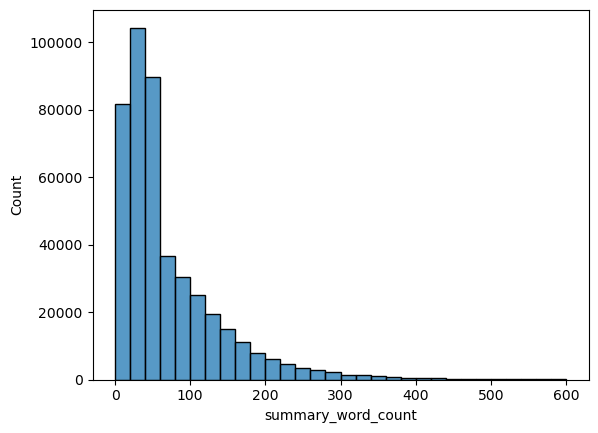

In [8]:
# count summary words
summary_limit = 600
game_df['summary_word_count'] = game_df['summary'].apply(lambda x: len(x.split()) if isinstance(x, str) else 0)
sns.histplot(game_df[game_df['summary_word_count'] <= summary_limit]['summary_word_count'], bins=30)

<Axes: xlabel='summary_length', ylabel='Count'>

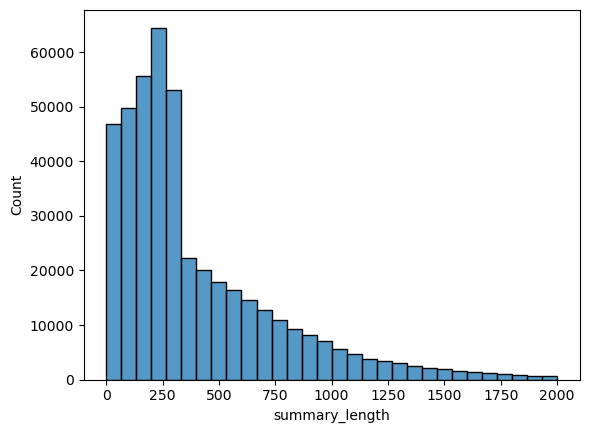

In [9]:
# summary length distribution for non missing, limit to x characters for better visualization

summary_limit = 2000
game_df['summary_length'] = game_df['summary'].apply(lambda x: len(x) if isinstance(x, str) else 0)
sns.histplot(game_df[game_df['summary_length'] <= summary_limit]['summary_length'], bins=30)


In [10]:
# sample of shortest descriptions and longest descriptions
shortest_summaries = game_df.nsmallest(10, 'summary_length')[['name', 'summary_length', 'summary']]
longest_summaries = game_df.nlargest(10, 'summary_length')[['name', 'summary_length', 'summary']]

print("Shortest Summaries:")
print(shortest_summaries.to_string(index=False))
print("\nLongest Summaries:")
print(longest_summaries.to_string(index=False))

Shortest Summaries:
                                             name  summary_length summary
0 Kara no Mahjong: Mahjong Youchien - Tamago Gumi               0     NaN
     0 Kara no Shogi: Shogi Youchien - Ayumi Kumi               0     NaN
                          007 - Ein Quantum Trost               0     NaN
                         007: Nagusame no Houshuu               0     NaN
                         007: Nagusame no Houshuu               0     NaN
     007: Quantum of Solace [Collector's Edition]               0     NaN
                            038 Tilemap generator               0     NaN
                       #1 Anagrams Sudokus Bundle               0     NaN
                                        1-Bit DAC               0     NaN
                             #1 Crosswords Bundle               0     NaN

Longest Summaries:
                       name  summary_length                                                                                                       

For ML mode

<Axes: xlabel='release_year', ylabel='Count'>

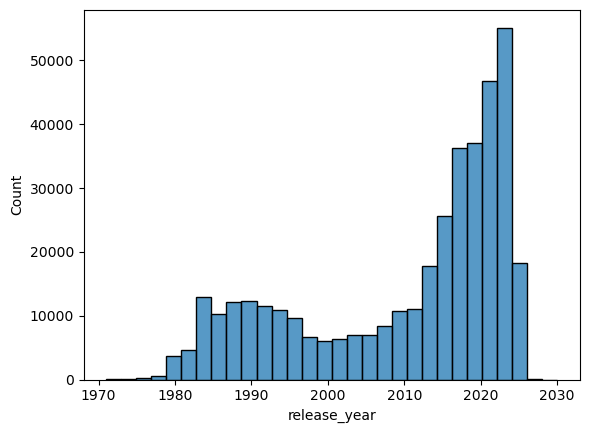

In [11]:
# release_year distribution for values over 1970
sns.histplot(game_df[game_df['release_year'] > 1970]['release_year'], bins=30)

In [12]:
# dev and publisher counts
print("Unique developer count:", game_df['developer'].nunique())
print("Unique publisher count:", game_df['publisher'].nunique())

Unique developer count: 89162
Unique publisher count: 69025


In [13]:
# most popular developer
top_developers = game_df['developer'].value_counts().head(10)
print("Top 10 Developers:")
print(top_developers)

# top publisher
top_publishers = game_df['publisher'].value_counts().head(10)
print("\nTop 10 Publishers:")
print(top_publishers)

Top 10 Developers:
developer
Konami         2110
Capcom         1382
Namco           791
Taito           776
Koei            759
Sega            730
SNK             715
Hudson Soft     664
Nintendo        643
Infocom         553
Name: count, dtype: int64

Top 10 Publishers:
publisher
Nintendo                   3078
Freeware, Public Domain    3001
Konami                     2842
Electronic Arts            2484
Sega                       2203
Activision                 1752
Capcom                     1594
Square Enix                1177
Freeware                   1169
THQ                         975
Name: count, dtype: int64


In [14]:
# duplicate rates, not including platforms
duplicate_names = game_df['name'].duplicated().sum()
total_entries = len(game_df)
duplicate_rate = duplicate_names / total_entries * 100
print(f"\nDuplicate game names: {duplicate_names} ({duplicate_rate:.2f}%)")


Duplicate game names: 178615 (39.80%)


In [15]:
# metadata completeness by row

metadata_fields = ['summary', 'genres', 'release_year']

cumulative_non_missing = []

for i in range(len(metadata_fields)):
    cols = metadata_fields[: i + 1]
    row_count = game_df[cols].notna().all(axis=1).sum()
    row_pct = (row_count / len(game_df)) * 100

    cumulative_non_missing.append({
        "field_set": tuple(cols),
        "row_count": int(row_count),
        "row_pct": row_pct
    })

    print(
        f"{i+1:2d}. {tuple(cols)} -> {row_pct:.2f}% "
        f"({row_count:,}/{len(game_df):,})"
    )



 1. ('summary',) -> 94.55% (424,305/448,740)
 2. ('summary', 'genres') -> 89.12% (399,918/448,740)
 3. ('summary', 'genres', 'release_year') -> 79.22% (355,497/448,740)
